In [2]:
import numpy as np
stable_weights = np.load("results/stable_weights.npy")

In [3]:
stable_weights.shape

(234, 25)

Num weights: 234
Mean MSE: 0.437504  ± 0.370192


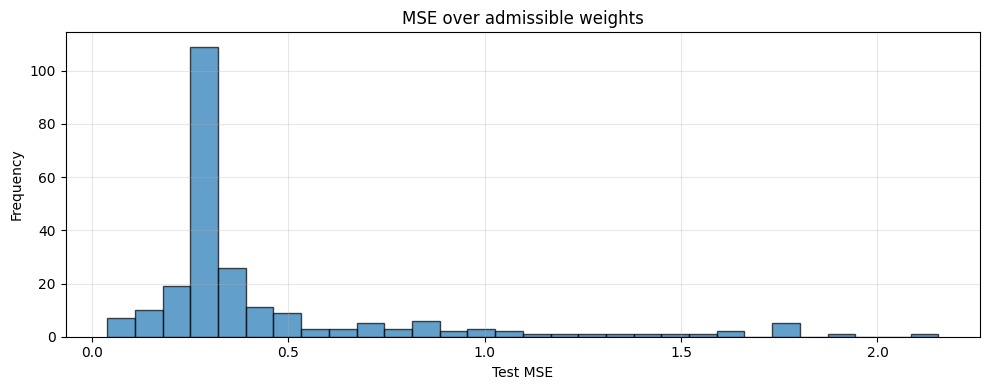

In [13]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

stable_weights = np.load("results/stable_weights.npy")  # (454, 25)

model = nn.Sequential(
    nn.Linear(1, 8),
    nn.Tanh(),
    nn.Linear(8, 1)
)

def set_model_weights(model, w_vec):
    w_vec = np.asarray(w_vec).ravel()
    idx = 0
    for p in model.parameters():
        n = p.numel()
        slice_ = w_vec[idx:idx+n]
        p.data = torch.tensor(slice_.reshape(p.shape), dtype=torch.float32)
        idx += n

X_test = torch.linspace(-1, 1, 200).unsqueeze(1)
y_test = torch.sin(X_test)
y_mean = y_test.mean()

mses = []
r2s = []

for w in stable_weights:
    set_model_weights(model, w)
    with torch.no_grad():
        y_pred = model(X_test)
        mse = ((y_pred - y_test)**2).mean().item()
        ss_res = ((y_pred - y_test)**2).sum().item()
        ss_tot = ((y_test - y_mean)**2).sum().item()
        r2 = 1.0 - ss_res / ss_tot
    mses.append(mse)
    r2s.append(r2)

mses = np.array(mses)
r2s = np.array(r2s)

print(f"Num weights: {len(mses)}")
print(f"Mean MSE: {mses.mean():.6f}  ± {mses.std():.6f}")


plt.figure(figsize=(10,4))

plt.hist(mses, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("Test MSE")
plt.ylabel("Frequency")
plt.title("MSE over admissible weights")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

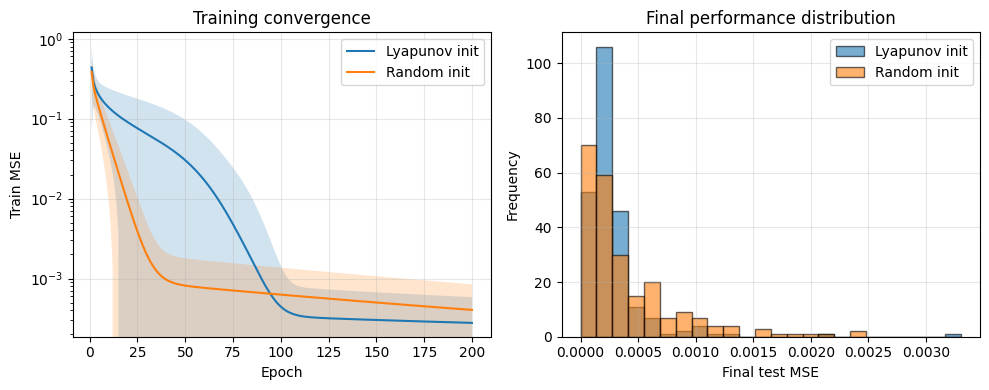

Lyapunov init: mean final MSE = 0.00027799524892761215
Random init:   mean final MSE = 0.0004031011901928588


In [5]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

stable_weights = np.load("results/stable_weights.npy")

def make_model():
    return nn.Sequential(
        nn.Linear(1, 8),
        nn.Tanh(),
        nn.Linear(8, 1)
    )

def set_model_weights(model, w_vec):
    w_vec = np.asarray(w_vec).ravel()
    idx = 0
    for p in model.parameters():
        n = p.numel()
        slice_ = w_vec[idx:idx+n]
        p.data = torch.tensor(slice_.reshape(p.shape), dtype=torch.float32)
        idx += n

def train_one_run(model, X, y, n_epochs=20, lr=0.1):
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    losses = []
    for _ in range(n_epochs):
        opt.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return np.array(losses), model

X_train = torch.linspace(-1, 1, 200).unsqueeze(1)
y_train = torch.sin(X_train)
X_test, y_test = X_train, y_train

n_epochs = 200
lr = 0.1
n_runs = 50  

losses_stable = []
final_mse_stable = []

for w in stable_weights:
    model = make_model()
    set_model_weights(model, w)
    losses, trained = train_one_run(model, X_train, y_train, n_epochs, lr)
    losses_stable.append(losses)
    with torch.no_grad():
        y_pred = trained(X_test)
        mse = ((y_pred - y_test)**2).mean().item()
    final_mse_stable.append(mse)

losses_stable = np.stack(losses_stable)
final_mse_stable = np.array(final_mse_stable)

losses_random = []
final_mse_random = []

for _ in range(len(stable_weights)):
    model = make_model()
    losses, trained = train_one_run(model, X_train, y_train, n_epochs, lr)
    losses_random.append(losses)
    with torch.no_grad():
        y_pred = trained(X_test)
        mse = ((y_pred - y_test)**2).mean().item()
    final_mse_random.append(mse)

losses_random = np.stack(losses_random)
final_mse_random = np.array(final_mse_random)

epochs = np.arange(1, n_epochs+1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs, losses_stable.mean(axis=0), label="Lyapunov init")
plt.fill_between(epochs,
                 losses_stable.mean(axis=0) - losses_stable.std(axis=0),
                 losses_stable.mean(axis=0) + losses_stable.std(axis=0),
                 alpha=0.2)
plt.plot(epochs, losses_random.mean(axis=0), label="Random init")
plt.fill_between(epochs,
                 losses_random.mean(axis=0) - losses_random.std(axis=0),
                 losses_random.mean(axis=0) + losses_random.std(axis=0),
                 alpha=0.2)
plt.xlabel("Epoch")
plt.ylabel("Train MSE")
plt.title("Training convergence")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1,2,2)
bins = np.linspace(0, max(final_mse_stable.max(), final_mse_random.max()), 25)
plt.hist(final_mse_stable, bins=bins, alpha=0.6, label="Lyapunov init", edgecolor="black")
plt.hist(final_mse_random, bins=bins, alpha=0.6, label="Random init", edgecolor="black")
plt.xlabel("Final test MSE")
plt.ylabel("Frequency")
plt.title("Final performance distribution")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("Lyapunov init: mean final MSE =", final_mse_stable.mean())
print("Random init:   mean final MSE =", final_mse_random.mean())

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from pinn_lyap_nn import LyapunovNet, NNDynamics, ResNetDynamics, TinyResNet
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def make_model():
    return TinyResNet().to(device)

def set_model_weights(model, w_vec):
    """w_vec: numpy [state_dim] from your admissible set"""
    w_vec = np.asarray(w_vec).ravel()
    idx = 0
    with torch.no_grad():
        for p in model.parameters():
            n = p.numel()
            chunk = w_vec[idx:idx+n]
            p.copy_(torch.tensor(chunk.reshape(p.shape), dtype=torch.float32, device=device))
            idx += n

def flatten_params(model):
    params = []
    for p in model.parameters():
        params.append(p.data.detach().cpu().numpy().ravel())
    return np.concatenate(params)

tmp_model = make_model()
print("Model param dim:", flatten_params(tmp_model).shape[0])

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

n_train = 10000
n_test  = 500
train_idx = np.random.choice(len(train_dataset), n_train, replace=False)
test_idx  = np.random.choice(len(test_dataset),  n_test,  replace=False)

train_loader = DataLoader(Subset(train_dataset, train_idx), batch_size=64, shuffle=True)
test_loader  = DataLoader(Subset(test_dataset,  test_idx),  batch_size=64, shuffle=False)

Model param dim: 2730


In [ ]:
stable_weights = np.load("results/stable_weights.npy")  
print("Num stable weights:", len(stable_weights))
print("State dim:", stable_weights[0].shape[0])

def train_one_run(model, train_loader, test_loader, n_epochs=10, lr=0.01):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    train_losses = []
    test_accs = []

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        n_batches = 0

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            opt.zero_grad()
            logits = model(X)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()

            running_loss += loss.item()
            n_batches += 1

        train_losses.append(running_loss / n_batches)

        # Evaluate
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in test_loader:
                X = X.to(device)
                y = y.to(device)
                logits = model(X)
                preds = logits.argmax(dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)
        acc = 100.0 * correct / total
        test_accs.append(acc)

    return np.array(train_losses), np.array(test_accs)

n_epochs = 50
lr = 0.01

n_runs = min(10, len(stable_weights))   # e.g. test first 50 admissible weights

losses_stable = []
accs_stable = []

for i in tqdm(range(n_runs), desc="Stable inits"):
    w = stable_weights[i]
    model = make_model()
    set_model_weights(model, w)
    tr_loss, te_acc = train_one_run(model, train_loader, test_loader, n_epochs=n_epochs, lr=lr)
    losses_stable.append(tr_loss)
    accs_stable.append(te_acc)

losses_stable = np.stack(losses_stable)
accs_stable   = np.stack(accs_stable)

losses_random = []
accs_random = []

for i in tqdm(range(n_runs), desc="Random inits"):
    model = make_model()  # default PyTorch init
    tr_loss, te_acc = train_one_run(model, train_loader, test_loader, n_epochs=n_epochs, lr=lr)
    losses_random.append(tr_loss)
    accs_random.append(te_acc)

losses_random = np.stack(losses_random)
accs_random   = np.stack(accs_random)

epochs = np.arange(1, n_epochs+1)

plt.figure(figsize=(12,5))

# Train loss
plt.subplot(1,2,1)
m_stable = losses_stable.mean(axis=0)
s_stable = losses_stable.std(axis=0)
m_rand   = losses_random.mean(axis=0)
s_rand   = losses_random.std(axis=0)

plt.plot(epochs, m_stable, label="Lyapunov init")
plt.fill_between(epochs, m_stable - s_stable, m_stable + s_stable, alpha=0.2)

plt.plot(epochs, m_rand, label="Random init")
plt.fill_between(epochs, m_rand - s_rand, m_rand + s_rand, alpha=0.2)

plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.yscale("log")
plt.title("Training convergence (CIFAR10, TinyResNet)")
plt.grid(alpha=0.3)
plt.legend()

# Test accuracy
plt.subplot(1,2,2)
m_stable_acc = accs_stable.mean(axis=0)
s_stable_acc = accs_stable.std(axis=0)
m_rand_acc   = accs_random.mean(axis=0)
s_rand_acc   = accs_random.std(axis=0)

plt.plot(epochs, m_stable_acc, label="Lyapunov init")
plt.fill_between(epochs, m_stable_acc - s_stable_acc, m_stable_acc + s_stable_acc, alpha=0.2)

plt.plot(epochs, m_rand_acc, label="Random init")
plt.fill_between(epochs, m_rand_acc - s_rand_acc, m_rand_acc + s_rand_acc, alpha=0.2)

plt.xlabel("Epoch")
plt.ylabel("Test accuracy (%)")
plt.title("Test accuracy over epochs")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Final accuracy histograms
final_acc_stable = accs_stable[:, -1]
final_acc_random = accs_random[:, -1]

plt.figure(figsize=(6,4))
bins = np.linspace(0, 100, 21)
plt.hist(final_acc_stable, bins=bins, alpha=0.6, label="Lyapunov init", edgecolor="black")
plt.hist(final_acc_random, bins=bins, alpha=0.6, label="Random init", edgecolor="black")
plt.xlabel("Final test accuracy (%)")
plt.ylabel("Frequency")
plt.title("Final performance distribution")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("Lyapunov init: mean final acc = ", final_acc_stable.mean())
print("Random init:   mean final acc = ", final_acc_random.mean())

Num stable weights: 391
State dim: 2730


Stable inits:  30%|███       | 3/10 [18:47<43:34, 373.46s/it]

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from lyap_resnet_pipeline import LyapunovNet, ResNetDynamics, TinyResNet
from tqdm import tqdm


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def make_model():
    return TinyResNet(initial_dim=1).to(device)


def set_model_weights(model, w_vec):
    """w_vec: numpy [state_dim] from your admissible set"""
    w_vec = np.asarray(w_vec).ravel()
    idx = 0
    with torch.no_grad():
        for p in model.parameters():
            n = p.numel()
            chunk = w_vec[idx:idx+n]
            p.copy_(torch.tensor(chunk.reshape(p.shape), dtype=torch.float32, device=device))
            idx += n


def flatten_params(model):
    params = []
    for p in model.parameters():
        params.append(p.data.detach().cpu().numpy().ravel())
    return np.concatenate(params)


tmp_model = make_model()
print("Model param dim:", flatten_params(tmp_model).shape[0])


# CHANGED: MNIST transform (grayscale, single channel)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])


# CHANGED: MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


n_train = 1000
n_test  = 50
train_idx = np.random.choice(len(train_dataset), n_train, replace=False)
test_idx  = np.random.choice(len(test_dataset),  n_test,  replace=False)


train_loader = DataLoader(Subset(train_dataset, train_idx), batch_size=64, shuffle=True)
test_loader  = DataLoader(Subset(test_dataset,  test_idx),  batch_size=64, shuffle=False)

Model param dim: 2586


In [4]:
stable_weights = np.load("training_info/results/1000_50_0.001/20260204_132226/stable_weights.npy")  
print("Num stable weights:", len(stable_weights))
print("State dim:", stable_weights[0].shape[0])


def train_one_run(model, train_loader, test_loader, n_epochs=10, lr=0.01):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    train_losses = []
    test_accs = []

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        n_batches = 0

        for X, y in train_loader:
            X = X.to(device)
            y = y.to(device)

            opt.zero_grad()
            logits = model(X)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()

            running_loss += loss.item()
            n_batches += 1

        train_losses.append(running_loss / n_batches)

        # Evaluate
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in test_loader:
                X = X.to(device)
                y = y.to(device)
                logits = model(X)
                preds = logits.argmax(dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)
        acc = 100.0 * correct / total
        test_accs.append(acc)

    return np.array(train_losses), np.array(test_accs)


n_epochs = 100
lr = 0.1

n_runs = min(100, len(stable_weights))

losses_stable = []
accs_stable = []

for i in tqdm(range(n_runs), desc="Stable inits"):
    w = stable_weights[i]
    model = make_model()
    set_model_weights(model, w)
    tr_loss, te_acc = train_one_run(model, train_loader, test_loader, n_epochs=n_epochs, lr=lr)
    losses_stable.append(tr_loss)
    accs_stable.append(te_acc)

losses_stable = np.stack(losses_stable)
accs_stable   = np.stack(accs_stable)

losses_random = []
accs_random = []

for i in tqdm(range(n_runs), desc="Random inits"):
    scales = np.random.uniform(0.1, 1)
    w_random = np.random.randn(stable_weights[i].shape[0]).astype(np.float32) * scales
    model = make_model()  # default PyTorch init
    set_model_weights(model, w_random)
    tr_loss, te_acc = train_one_run(model, train_loader, test_loader, n_epochs=n_epochs, lr=lr)
    losses_random.append(tr_loss)
    accs_random.append(te_acc)

losses_random = np.stack(losses_random)
accs_random   = np.stack(accs_random)

epochs = np.arange(1, n_epochs+1)

plt.figure(figsize=(12,5))

# Train loss
plt.subplot(1,2,1)
m_stable = losses_stable.mean(axis=0)
s_stable = losses_stable.std(axis=0)
m_rand   = losses_random.mean(axis=0)
s_rand   = losses_random.std(axis=0)

plt.plot(epochs, m_stable, label="Lyapunov init")
plt.fill_between(epochs, m_stable - s_stable, m_stable + s_stable, alpha=0.2)

plt.plot(epochs, m_rand, label="Random init")
plt.fill_between(epochs, m_rand - s_rand, m_rand + s_rand, alpha=0.2)

plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.yscale("log")
plt.title("Training convergence (MNIST, TinyResNet)")  # CHANGED title
plt.grid(alpha=0.3)
plt.legend()

# Test accuracy
plt.subplot(1,2,2)
m_stable_acc = accs_stable.mean(axis=0)
s_stable_acc = accs_stable.std(axis=0)
m_rand_acc   = accs_random.mean(axis=0)
s_rand_acc   = accs_random.std(axis=0)

plt.plot(epochs, m_stable_acc, label="Lyapunov init")
plt.fill_between(epochs, m_stable_acc - s_stable_acc, m_stable_acc + s_stable_acc, alpha=0.2)

plt.plot(epochs, m_rand_acc, label="Random init")
plt.fill_between(epochs, m_rand_acc - s_rand_acc, m_rand_acc + s_rand_acc, alpha=0.2)

plt.xlabel("Epoch")
plt.ylabel("Test accuracy (%)")
plt.title("Test accuracy over epochs")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('mnist_training_comparison.png', dpi=150)
plt.show()

# Final accuracy histograms
final_acc_stable = accs_stable[:, -1]
final_acc_random = accs_random[:, -1]

plt.figure(figsize=(6,4))
bins = np.linspace(0, 100, 21)
plt.hist(final_acc_stable, bins=bins, alpha=0.6, label="Lyapunov init", edgecolor="black")
plt.hist(final_acc_random, bins=bins, alpha=0.6, label="Random init", edgecolor="black")
plt.xlabel("Final test accuracy (%)")
plt.ylabel("Frequency")
plt.title("Final performance distribution (MNIST)")  # CHANGED title
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('mnist_final_accuracy_histogram.png', dpi=150)
plt.show()

print("Lyapunov init: mean final acc = ", final_acc_stable.mean())
print("Random init:   mean final acc = ", final_acc_random.mean())

Num stable weights: 95
State dim: 2586


Random inits: 100%|██████████| 95/95 [1:38:12<00:00, 62.02s/it]


Lyapunov init: mean final acc =  73.57894736842105
Random init:   mean final acc =  71.22105263157894


/var/folders/7s/rsmhzk0n3xnb2_stb95p_vkh0000gn/T/ipykernel_61712/236666507.py:130: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/7s/rsmhzk0n3xnb2_stb95p_vkh0000gn/T/ipykernel_61712/236666507.py:146: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
